# Titanic dataset

Goal: train a classifier that can predict the Survived column based on the other columns

## Setup

In [186]:
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

## Load Data

In [63]:
def load_titanic_data():
    tarball_path = Path("datasets/titanic.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/titanic.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as titanic_tarball:
            titanic_tarball.extractall(path="datasets")
    return [pd.read_csv(Path("datasets/titanic") / filename)
            for filename in ("train.csv", "test.csv")]

## Prepare train and test datasets

This is the Kagle competition. The test_df does not contain the label.
Conclusion: use train_df as full dataset

In [145]:
kaggle_train_df, kaggle_test_df = load_titanic_data()
full_df = kaggle_train_df

In [146]:
X, y = full_df.drop("Survived", axis=1), full_df["Survived"]

In [66]:
X.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [67]:
y

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [68]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Pclass       891 non-null    int64  
 2   Name         891 non-null    object 
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    object 
 8   Fare         891 non-null    float64
 9   Cabin        204 non-null    object 
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 76.7+ KB


In [69]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: Survived
Non-Null Count  Dtype
--------------  -----
891 non-null    int64
dtypes: int64(1)
memory usage: 7.1 KB


The label ballance needs to be inspected to decide on what type of split to do:

In [70]:
y.value_counts() / y.count()

,count
Survived,
0,0.616162
1,0.383838


Survived is imbalanced (≈62% died, ≈38% survived) => use a stratified split.

In [147]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,random_state=42,stratify=y
    )

In [72]:
y_train.value_counts() / y_train.count()

,count
Survived,
0,0.616573
1,0.383427


In [73]:
y_test.value_counts() / y_test.count()

,count
Survived,
0,0.614525
1,0.385475


## Label EDA


<Axes: >

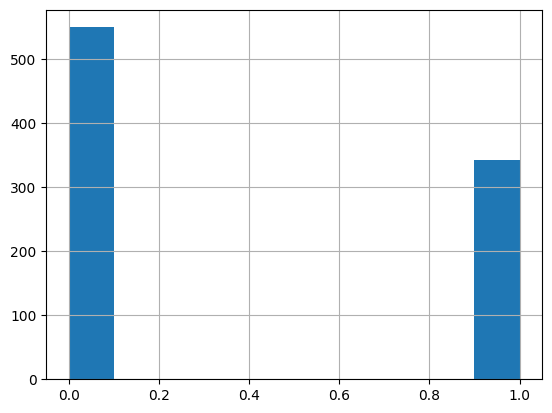

In [57]:
y.hist()

## Features EDA

In [74]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 692 to 507
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Pclass       712 non-null    int64  
 2   Name         712 non-null    object 
 3   Sex          712 non-null    object 
 4   Age          575 non-null    float64
 5   SibSp        712 non-null    int64  
 6   Parch        712 non-null    int64  
 7   Ticket       712 non-null    object 
 8   Fare         712 non-null    float64
 9   Cabin        160 non-null    object 
 10  Embarked     710 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 66.8+ KB


### "Name"
do not use Name. extract titles and use as categorical feature

In [61]:
X_train.head(30)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
692,693,3,"Lam, Mr. Ali",male,NaN,0,0,1601,56.4958,NaN,S
481,482,2,"Frost, Mr. Anthony Wood 'Archie'",male,NaN,0,0,239854,0.0000,NaN,S
527,528,1,"Farthing, Mr. John",male,NaN,0,0,PC 17483,221.7792,C95,S
855,856,3,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,392091,9.3500,NaN,S
801,802,2,"Collyer, Mrs. Harvey (Charlotte Annie Tate)",female,31.0,1,1,C.A. 31921,26.2500,NaN,S
652,653,3,"Kalvik, Mr. Johannes Halvorsen",male,21.0,0,0,8475,8.4333,NaN,S
509,510,3,"Lang, Mr. Fang",male,26.0,0,0,1601,56.4958,NaN,S
557,558,1,"Robbins, Mr. Victor",male,NaN,0,0,PC 17757,227.5250,NaN,C
828,829,3,"McCormack, Mr. Thomas Joseph",male,NaN,0,0,367228,7.7500,NaN,Q
18,19,3,"Vander Planke, Mrs. Julius (Emelia Maria Vande...",female,31.0,1,0,345763,18.0000,NaN,S


In [148]:
import re

def extract_title(name):
    match = re.search(r", (.*?)\.", name)
    return match.group(1) if match else ""

X_train["Title"] = X_train["Name"].apply(extract_title)
X_test["Title"]  = X_test["Name"].apply(extract_title)

X_train.drop("Name", axis=1, inplace=True)
X_test.drop("Name", axis=1, inplace=True)


In [77]:
X_train.head(5)

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
692,693,3,male,NaN,0,0,1601,56.4958,NaN,S,Mr
481,482,2,male,NaN,0,0,239854,0.0000,NaN,S,Mr
527,528,1,male,NaN,0,0,PC 17483,221.7792,C95,S,Mr
855,856,3,female,18.0,0,1,392091,9.3500,NaN,S,Mrs
801,802,2,female,31.0,1,1,C.A. 31921,26.2500,NaN,S,Mrs


In [80]:
X_train["Title"].value_counts()

,count
Title,
Mr,412
Miss,141
Mrs,107
Master,31
Dr,6
Rev,5
Mlle,2
Col,2
Major,1


In [149]:
rare_titles = ["Dr","Rev","Mlle","Col","Major","Lady","Sir","Ms","Jonkheer","Don"]
X_train["Title"] = X_train["Title"].replace(rare_titles, "Rare")
X_test["Title"]  = X_test["Title"].replace(rare_titles, "Rare")
X_train["Title"].value_counts()

,count
Title,
Mr,412
Miss,141
Mrs,107
Master,31
Rare,21


## "Pclass"
categorical

<Axes: >

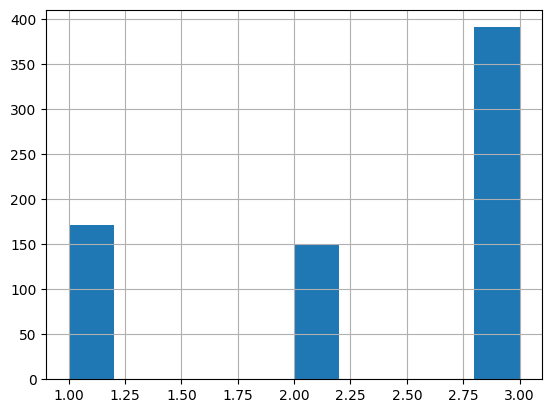

In [84]:
X_train["Pclass"].hist()

In [87]:
X_train["Pclass"].isnull().sum()

np.int64(0)

In [89]:
X_train.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
692,693,3,male,NaN,0,0,1601,56.4958,NaN,S,Mr
481,482,2,male,NaN,0,0,239854,0.0000,NaN,S,Mr
527,528,1,male,NaN,0,0,PC 17483,221.7792,C95,S,Mr
855,856,3,female,18.0,0,1,392091,9.3500,NaN,S,Mrs
801,802,2,female,31.0,1,1,C.A. 31921,26.2500,NaN,S,Mrs


## "Sex"
add Sex as categorical
2/3 of dataset are male

In [90]:
X_train["Sex"].isnull().sum()

np.int64(0)

In [92]:
X_train["Sex"].value_counts()

,count
Sex,
male,459
female,253


## "Age"

<Axes: >

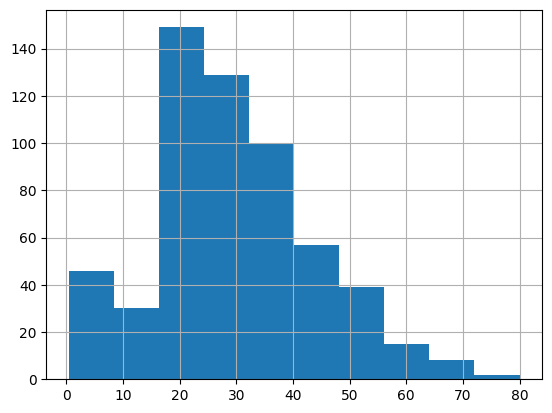

In [93]:
X_train["Age"].hist()

In [97]:
X_train["Age"].isnull().sum()

np.int64(137)

A lot of age features are missing, but it could has strong predictor for survival.
Conclusion:
- add feature "age_missing"
- Impute missing age by median within Title

In [150]:
X_train["Age_missing"] = X_train["Age"].isna().astype(int)
X_test["Age_missing"]  = X_test["Age"].isna().astype(int)

In [99]:
X_train["Age_missing"].value_counts()

,count
Age_missing,
0,575
1,137


In [151]:
from numpy import median

# Impute by median within Title

X_train["Age"] = X_train.groupby("Title")["Age"].transform(
    lambda x: x.fillna(x.median())
)
X_test["Age"] = X_test.groupby("Title")["Age"].transform(
    lambda x: x.fillna(x.median())
)

<Axes: >

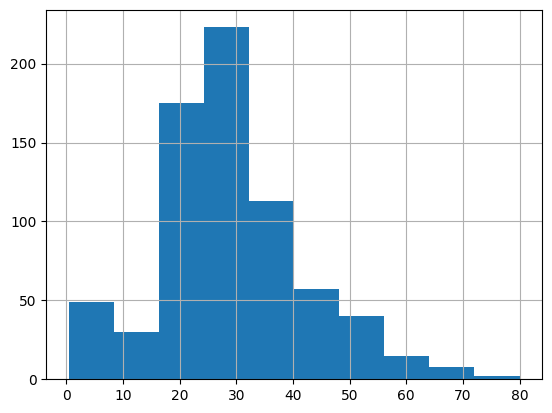

In [106]:
X_train["Age"].hist()

In [107]:
X_train["Age"].isnull().sum()

np.int64(0)

In [152]:
# optional: binning is good for logistic regression
bins = [0, 12, 18, 35, 60, 100]
labels = ["Child","Teen","YoungAdult","Adult","Senior"]

X_train["Age_bin"] = pd.cut(X_train["Age"], bins=bins, labels=labels)
X_test["Age_bin"]  = pd.cut(X_test["Age"], bins=bins, labels=labels)

In [109]:
X_train.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Age_missing,Age_bin
692,693,3,male,30.0,0,0,1601,56.4958,NaN,S,Mr,1,YoungAdult
481,482,2,male,30.0,0,0,239854,0.0000,NaN,S,Mr,1,YoungAdult
527,528,1,male,30.0,0,0,PC 17483,221.7792,C95,S,Mr,1,YoungAdult
855,856,3,female,18.0,0,1,392091,9.3500,NaN,S,Mrs,0,Teen
801,802,2,female,31.0,1,1,C.A. 31921,26.2500,NaN,S,Mrs,0,YoungAdult


## "SibSp" and "Parch"


Examples
Passenger,	Traveling with,	SibSp,	Parch

Single man, alone, 	nobody	0	0

Woman with husband, spouse	1	0

Boy with parents, mom & dad	0	2

Mother with baby, child	0	1

Man with wife + 2 kids	wife + 2 children	1	2

Sisters traveling together	1 sibling	1	0


<Axes: >

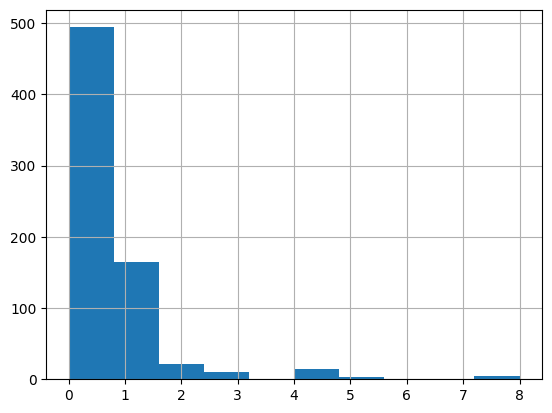

In [111]:
X_train["SibSp"].hist()

In [112]:
X_train["SibSp"].isnull().sum()

np.int64(0)

In [113]:
X_train["SibSp"].value_counts()

,count
SibSp,
0,494
1,164
2,21
4,15
3,10
8,5
5,3


In [114]:
X_train["Parch"].isnull().sum()

np.int64(0)

<Axes: >

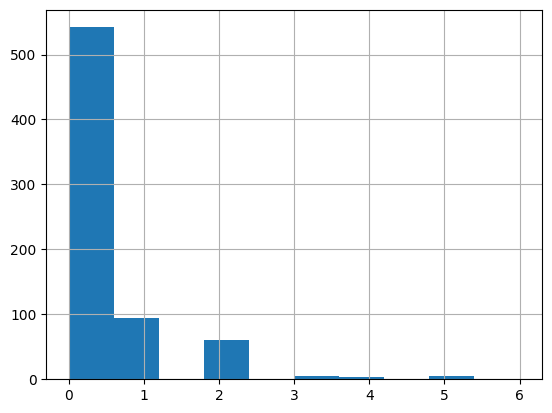

In [115]:
X_train["Parch"].hist()

In [153]:
# FamilySize = SibSp + Parch + 1
# +1 for the passenger
X_train["FamilySize"] = X_train["SibSp"] + X_train["Parch"] + 1
X_test["FamilySize"]  = X_test["SibSp"]  + X_test["Parch"]  + 1

<Axes: >

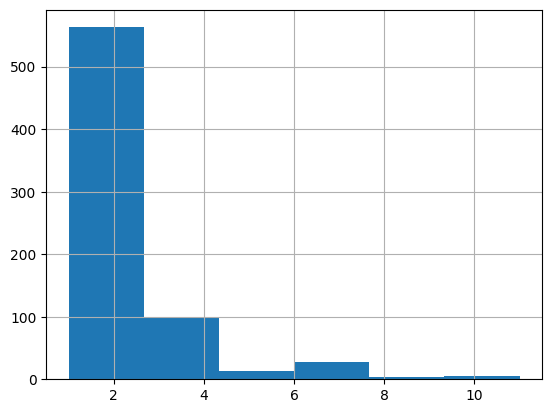

In [177]:
X_train["FamilySize"].hist(bins=6)

In [154]:
X_train["FamilyGroup"] = pd.cut(
    X_train["FamilySize"], bins=[0,1,4,11], labels=["Solo","Small","Large"]
)
X_test["FamilyGroup"] = pd.cut(
    X_test["FamilySize"], bins=[0,1,4,11], labels=["Solo","Small","Large"]
)

In [121]:
X_train.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Age_missing,Age_bin,FamilySize,FamilyGroup
692,693,3,male,30.0,0,0,1601,56.4958,NaN,S,Mr,1,YoungAdult,1,Solo
481,482,2,male,30.0,0,0,239854,0.0000,NaN,S,Mr,1,YoungAdult,1,Solo
527,528,1,male,30.0,0,0,PC 17483,221.7792,C95,S,Mr,1,YoungAdult,1,Solo
855,856,3,female,18.0,0,1,392091,9.3500,NaN,S,Mrs,0,Teen,2,Small
801,802,2,female,31.0,1,1,C.A. 31921,26.2500,NaN,S,Mrs,0,YoungAdult,3,Small


## "Ticket"

In [155]:
import re

def ticket_prefix(t):
    t = t.replace(".", "").replace("/", "")
    parts = t.split()
    return parts[0] if not parts[0].isdigit() else "NUMERIC"

X_train["TicketPrefix"] = X_train["Ticket"].apply(ticket_prefix)
X_test["TicketPrefix"]  = X_test["Ticket"].apply(ticket_prefix)


In [156]:
X_train.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Age_missing,Age_bin,FamilySize,FamilyGroup,TicketPrefix
692,693,3,male,30.0,0,0,1601,56.4958,NaN,S,Mr,1,YoungAdult,1,Solo,NUMERIC
481,482,2,male,30.0,0,0,239854,0.0000,NaN,S,Mr,1,YoungAdult,1,Solo,NUMERIC
527,528,1,male,30.0,0,0,PC 17483,221.7792,C95,S,Mr,1,YoungAdult,1,Solo,PC
855,856,3,female,18.0,0,1,392091,9.3500,NaN,S,Mrs,0,Teen,2,Small,NUMERIC
801,802,2,female,31.0,1,1,C.A. 31921,26.2500,NaN,S,Mrs,0,YoungAdult,3,Small,CA


In [158]:
X_train["TicketPrefix"].value_counts()

,count
TicketPrefix,
NUMERIC,522
PC,54
CA,32
A5,20
SOTONOQ,11
STONO,10
WC,10
SCPARIS,6
A4,6


In [159]:
# Mark rare prefixes using *train* counts
min_count = 10
prefix_counts = X_train["TicketPrefix"].value_counts()

rare_prefixes = set(prefix_counts[prefix_counts < min_count].index)

def collapse_rare(p):
    return "Rare" if p in rare_prefixes else p

X_train["TicketPrefix"] = X_train["TicketPrefix"].apply(collapse_rare)
X_test["TicketPrefix"]  = X_test["TicketPrefix"].apply(
    lambda p: "Rare" if (p in rare_prefixes or p not in prefix_counts.index) else p
)

# (Optional) Extra numeric feature: ticket number length
# X_train["TicketNumLen"] = X_train["Ticket"].str.extract(r"(\d+)").iloc[:,0].str.len()
# X_test["TicketNumLen"]  = X_test["Ticket"].str.extract(r"(\d+)").iloc[:,0].str.len()

# (Optional) Drop the raw Ticket string after extraction
# X_train = X_train.drop(columns=["Ticket"])
# X_test  = X_test.drop(columns=["Ticket"])

<Axes: >

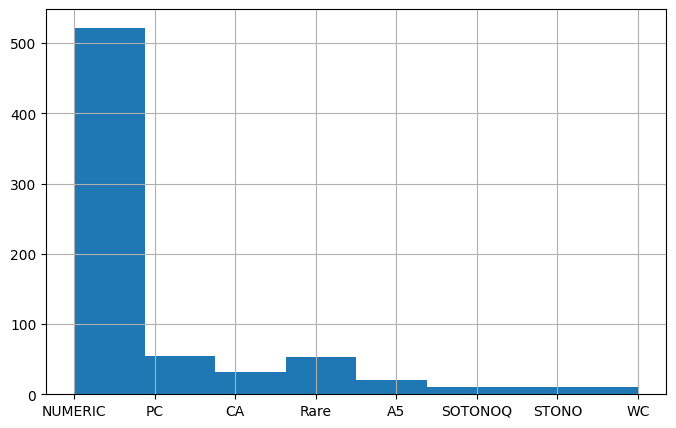

In [171]:
X_train["TicketPrefix"].hist(bins=8, figsize=(8, 5))

## "Fare"

In [165]:
X_train.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Age_missing,Age_bin,FamilySize,FamilyGroup,TicketPrefix
692,693,3,male,30.0,0,0,1601,56.4958,NaN,S,Mr,1,YoungAdult,1,Solo,NUMERIC
481,482,2,male,30.0,0,0,239854,0.0000,NaN,S,Mr,1,YoungAdult,1,Solo,NUMERIC
527,528,1,male,30.0,0,0,PC 17483,221.7792,C95,S,Mr,1,YoungAdult,1,Solo,PC
855,856,3,female,18.0,0,1,392091,9.3500,NaN,S,Mrs,0,Teen,2,Small,NUMERIC
801,802,2,female,31.0,1,1,C.A. 31921,26.2500,NaN,S,Mrs,0,YoungAdult,3,Small,CA


In [183]:
X_train["Fare"].describe()

,Fare
count,712.000000
mean,31.819826
std,48.059104
min,0.000000
25%,7.895800
50%,14.454200
75%,31.000000
max,512.329200


In [184]:
X_train["Fare"].isna()

,Fare
692,False
481,False
527,False
855,False
801,False
...,...
359,False
258,False
736,False
462,False


<Axes: >

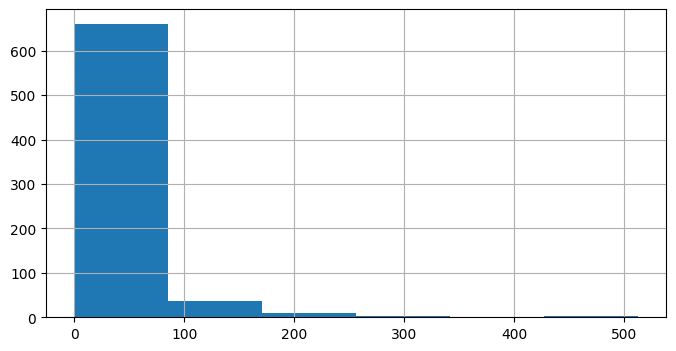

In [180]:
X_train["Fare"].hist(bins=6, figsize=(8,4))

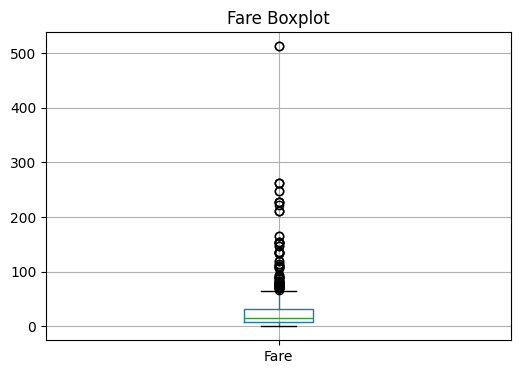

In [187]:
X_train.boxplot(column="Fare", figsize=(6,4))
plt.title("Fare Boxplot")
plt.show()

In [191]:
import numpy as np

X_train["Fare_log"] = np.log1p(X_train["Fare"]) # for linear models
X_test["Fare_log"]  = np.log1p(X_test["Fare"])


<Axes: >

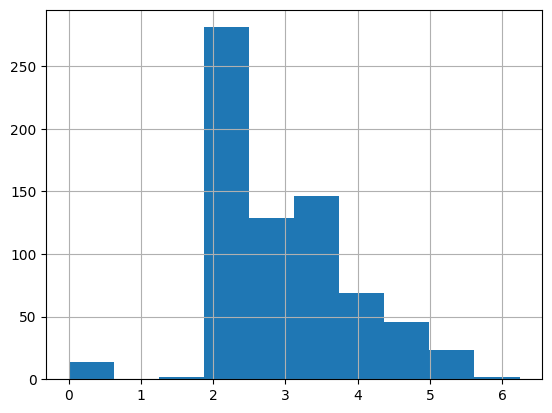

In [190]:
X_train["Fare_log"].hist()

In [193]:
X_train["Fare_bin"] = pd.qcut(X_train["Fare"], 4, labels=False) # for tree models
X_test["Fare_bin"]  = pd.qcut(X_test["Fare"], 4, labels=False)

In [196]:
X_train.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Age_missing,Age_bin,FamilySize,FamilyGroup,TicketPrefix,Fare_log
692,693,3,male,30.0,0,0,1601,56.4958,NaN,S,Mr,1,YoungAdult,1,Solo,NUMERIC,4.051712
481,482,2,male,30.0,0,0,239854,0.0000,NaN,S,Mr,1,YoungAdult,1,Solo,NUMERIC,0.000000
527,528,1,male,30.0,0,0,PC 17483,221.7792,C95,S,Mr,1,YoungAdult,1,Solo,PC,5.406181
855,856,3,female,18.0,0,1,392091,9.3500,NaN,S,Mrs,0,Teen,2,Small,NUMERIC,2.336987
801,802,2,female,31.0,1,1,C.A. 31921,26.2500,NaN,S,Mrs,0,YoungAdult,3,Small,CA,3.305054


## "Cabin"

In [200]:
X_train["Cabin"].isnull().sum()

np.int64(552)

In [201]:
X_train["Cabin_missing"] = X_train["Cabin"].isna().astype(int)
X_test["Cabin_missing"]  = X_test["Cabin"].isna().astype(int)


In [202]:
X_train["Deck"] = X_train["Cabin"].str[0]
X_test["Deck"]  = X_test["Cabin"].str[0]
X_train["Deck"] = X_train["Deck"].fillna("Unknown")
X_test["Deck"]  = X_test["Deck"].fillna("Unknown")

In [204]:
X_train.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Age_missing,Age_bin,FamilySize,FamilyGroup,TicketPrefix,Fare_log,Cabin_missing,Deck
692,693,3,male,30.0,0,0,1601,56.4958,NaN,S,Mr,1,YoungAdult,1,Solo,NUMERIC,4.051712,1,Unknown
481,482,2,male,30.0,0,0,239854,0.0000,NaN,S,Mr,1,YoungAdult,1,Solo,NUMERIC,0.000000,1,Unknown
527,528,1,male,30.0,0,0,PC 17483,221.7792,C95,S,Mr,1,YoungAdult,1,Solo,PC,5.406181,0,C
855,856,3,female,18.0,0,1,392091,9.3500,NaN,S,Mrs,0,Teen,2,Small,NUMERIC,2.336987,1,Unknown
801,802,2,female,31.0,1,1,C.A. 31921,26.2500,NaN,S,Mrs,0,YoungAdult,3,Small,CA,3.305054,1,Unknown


## "Embarked"

In [205]:
X_train["Embarked"].isnull().sum()

np.int64(2)

<Axes: >

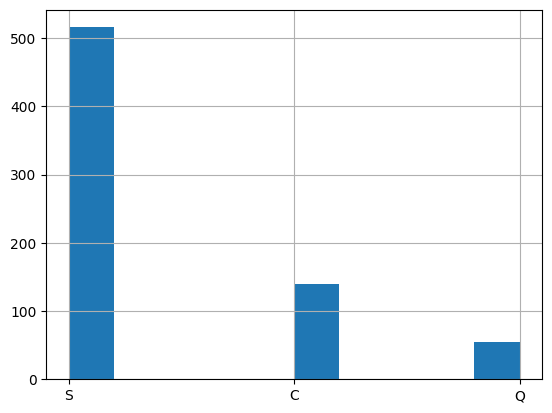

In [206]:
X_train["Embarked"].hist()

In [217]:
X_train["Embarked"] = X_train["Embarked"].fillna("S")
X_test["Embarked"]  = X_test["Embarked"].fillna("S")

<Axes: >

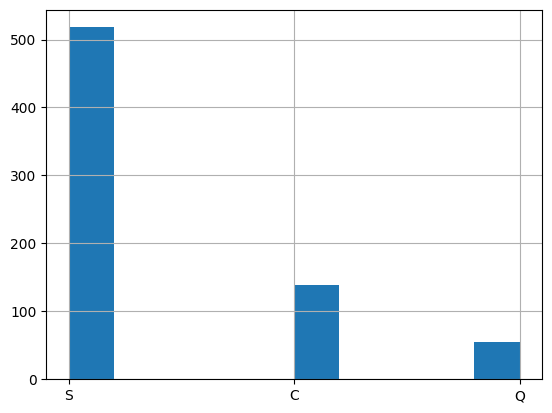

In [220]:
X_train["Embarked"].hist()

## Correlations

In [222]:
df_corr = X_train.copy()
df_corr["Survived"] = y_train

In [211]:
df_corr.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Age_missing,Age_bin,FamilySize,FamilyGroup,TicketPrefix,Fare_log,Cabin_missing,Deck,Survived
692,693,3,male,30.0,0,0,1601,56.4958,NaN,S,Mr,1,YoungAdult,1,Solo,NUMERIC,4.051712,1,Unknown,1
481,482,2,male,30.0,0,0,239854,0.0000,NaN,S,Mr,1,YoungAdult,1,Solo,NUMERIC,0.000000,1,Unknown,0
527,528,1,male,30.0,0,0,PC 17483,221.7792,C95,S,Mr,1,YoungAdult,1,Solo,PC,5.406181,0,C,0
855,856,3,female,18.0,0,1,392091,9.3500,NaN,S,Mrs,0,Teen,2,Small,NUMERIC,2.336987,1,Unknown,1
801,802,2,female,31.0,1,1,C.A. 31921,26.2500,NaN,S,Mrs,0,YoungAdult,3,Small,CA,3.305054,1,Unknown,1


In [223]:
df_corr.drop(columns=["PassengerId", "SibSp", "Parch", "Ticket", "Fare", "Cabin"], inplace=True)
df_corr.head()

,Pclass,Sex,Age,Embarked,Title,Age_missing,Age_bin,FamilySize,FamilyGroup,TicketPrefix,Fare_log,Cabin_missing,Deck,Survived
692,3,male,30.0,S,Mr,1,YoungAdult,1,Solo,NUMERIC,4.051712,1,Unknown,1
481,2,male,30.0,S,Mr,1,YoungAdult,1,Solo,NUMERIC,0.000000,1,Unknown,0
527,1,male,30.0,S,Mr,1,YoungAdult,1,Solo,PC,5.406181,0,C,0
855,3,female,18.0,S,Mrs,0,Teen,2,Small,NUMERIC,2.336987,1,Unknown,1
801,2,female,31.0,S,Mrs,0,YoungAdult,3,Small,CA,3.305054,1,Unknown,1


Numeric correlation heatmap

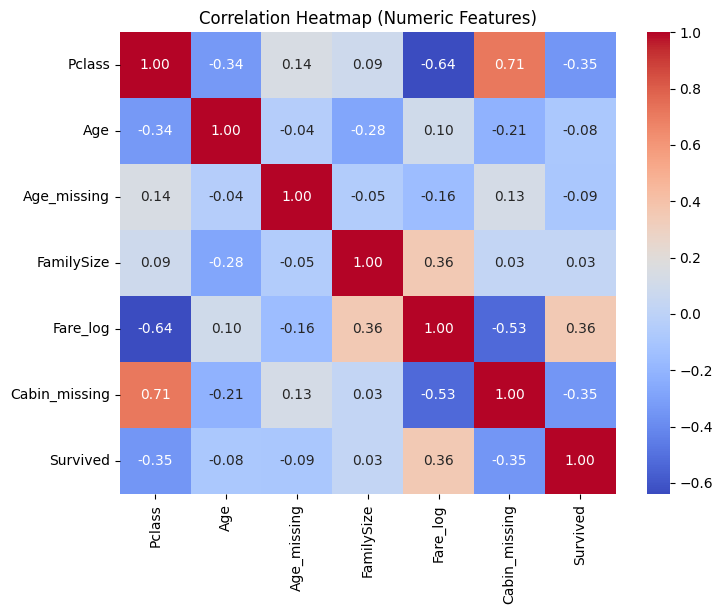

In [213]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(df_corr.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


In [214]:
df_corr.corr(numeric_only=True)["Survived"].sort_values(ascending=False)


,Survived
Survived,1.000000
Fare_log,0.355094
FamilySize,0.026967
Age,-0.083394
Age_missing,-0.091813
Pclass,-0.348007
Cabin_missing,-0.350535


In [225]:
for col in ["Title", "Pclass", "Sex", "Age_missing", "FamilyGroup",
            "TicketPrefix", "Deck", "Embarked", "Cabin_missing"]:
    print(df_corr.groupby(col)["Survived"].mean(), "\n")


Title
Master    0.548387
Miss      0.702128
Mr        0.152913
Mrs       0.785047
Rare      0.476190
Name: Survived, dtype: float64 

Pclass
1    0.649123
2    0.446667
3    0.242967
Name: Survived, dtype: float64 

Sex
female    0.743083
male      0.185185
Name: Survived, dtype: float64 

Age_missing
0    0.405217
1    0.291971
Name: Survived, dtype: float64 

FamilyGroup
Solo     0.299539
Small    0.592105
Large    0.160000
Name: Survived, dtype: float64 

TicketPrefix
A5         0.100000
CA         0.312500
NUMERIC    0.388889
PC         0.629630
Rare       0.301887
SOTONOQ    0.181818
STONO      0.500000
WC         0.100000
Name: Survived, dtype: float64 

Deck
A          0.428571
B          0.735294
C          0.682927
D          0.807692
E          0.758621
F          0.727273
G          0.500000
T          0.000000
Unknown    0.291667
Name: Survived, dtype: float64 

Embarked
C    0.561151
Q    0.436364
S    0.330116
Name: Survived, dtype: float64 

Cabin_missing
0    0.700000
1

/tmp/ipython-input-2041875479.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_corr.groupby(col)["Survived"].mean(), "\n")


## Summary

TODO: rename the file to EDA nad feature engineering

In [209]:
cat_cols = ["Title", "Pclass", "Sex", "Age_missing", "FamilyGroup",
            "TicketPrefix", "Deck", "Embarked", "Cabin_missing"]
num_cols = ["Age", "FamilySize", "Fare_log"]
optional_cat = ["Age_bin"] # for logistic regression and tree models

Do not forget to set imputations!!! Even if the train set does not have missing values, production data might have

## Save data

In [228]:
train_clean = df_corr
train_clean.head()

,Pclass,Sex,Age,Embarked,Title,Age_missing,Age_bin,FamilySize,FamilyGroup,TicketPrefix,Fare_log,Cabin_missing,Deck,Survived
692,3,male,30.0,S,Mr,1,YoungAdult,1,Solo,NUMERIC,4.051712,1,Unknown,1
481,2,male,30.0,S,Mr,1,YoungAdult,1,Solo,NUMERIC,0.000000,1,Unknown,0
527,1,male,30.0,S,Mr,1,YoungAdult,1,Solo,PC,5.406181,0,C,0
855,3,female,18.0,S,Mrs,0,Teen,2,Small,NUMERIC,2.336987,1,Unknown,1
801,2,female,31.0,S,Mrs,0,YoungAdult,3,Small,CA,3.305054,1,Unknown,1


In [229]:
test_clean = X_test.copy()
test_clean["Survived"] = y_test

In [231]:
test_clean.drop(columns=["PassengerId", "SibSp", "Parch", "Ticket", "Fare", "Cabin"], inplace=True)
test_clean.head()

,Pclass,Sex,Age,Embarked,Title,Age_missing,Age_bin,FamilySize,FamilyGroup,TicketPrefix,Fare_log,Cabin_missing,Deck,Survived
565,3,male,24.0,S,Mr,0,YoungAdult,3,Small,Rare,3.224858,1,Unknown,0
160,3,male,44.0,S,Mr,0,Adult,2,Small,NUMERIC,2.839078,1,Unknown,0
553,3,male,22.0,C,Mr,0,YoungAdult,1,Solo,NUMERIC,2.107178,1,Unknown,1
860,3,male,41.0,S,Mr,0,Adult,3,Small,NUMERIC,2.715244,1,Unknown,0
241,3,female,21.0,Q,Miss,1,YoungAdult,2,Small,NUMERIC,2.803360,1,Unknown,1


In [232]:
train_clean.to_csv("train.csv", index=False)
test_clean.to_csv("test.csv", index=False)
